## Linear Algebra
<p>
Performing basic operations using linear algebra using simple operations.
</p>

* Transpose
* Dot Product
* Inverse
* Determinant
* Norm 
* Rank
  

In [1]:
# Import numpy array aliased as np
import numpy as np

In [4]:
# Define a simple 2x2 matrix
A = np.array([[1, 2], 
              [3, 4]])
print(A)

[[1 2]
 [3 4]]


In [3]:
# Find the transpose of a matrix
transpose_A = A.T
print("Transpose:\n", transpose_A)

Transpose:
 [[1 3]
 [2 4]]


In [5]:
# Calculate the dot product
dot_product = np.dot(A, A)

print("Dot Product (A * A):\n", dot_product)

Dot Product (A * A):
 [[ 7 10]
 [15 22]]


In [6]:
# Finding the inverse of a matrix
inverse_A = np.linalg.inv(A)
print("Inverse:\n", inverse_A)

Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [7]:
# Find the determinant of A
det_A = np.linalg.det(A)
print("Determinant:", det_A)

Determinant: -2.0000000000000004


In [8]:
# Calculate the Norm (Frobenius norm) of matrices
norm_A = np.linalg.norm(A)
print("Norm:", norm_A)

Norm: 5.477225575051661


In [9]:
# Finding the Rank of a Matrix
rank_A = np.linalg.matrix_rank(A)
print("Rank:", rank_A)

Rank: 2


### Calulate the loss functions
The following are regression metrics and loss functions used in statistics and machine learning to measure how far a model's predictions are from the actual values.

In [11]:
import math

In [10]:
# Mean Absolute error to calculate the absolute loss from the predicted to the actual value
def calculate_mae(actual, predicted):
    total_error = 0
    for i in range(len(actual)):
        # Difference calculation of the actual and predicted value
        difference = actual[i] - predicted[i]
        # Return the total error 
        total_error = total_error + abs(difference)
    
    mae = total_error / len(actual)
    return mae

In [ ]:
# Mean Squared Error is to calulate the square of the absolute loss
def calculate_mse(actual, predicted):
    total_squared_error = 0
    for i in range(len(actual)):
        difference = actual[i] - predicted[i]
        total_squared_error = total_squared_error + (difference ** 2)
        
    mse = total_squared_error / len(actual)
    return mse

In [12]:
# RMSE is the Root of the MSE
def calculate_rmse(actual, predicted):
    total_squared_error = 0
    for i in range(len(actual)):
        difference = actual[i] - predicted[i]
        total_squared_error = total_squared_error + (difference ** 2)
        
    mse = total_squared_error / len(actual)
    rmse = math.sqrt(mse)
    return rmse

In [13]:
def calculate_r_squared(actual, predicted):
    # 1. Find the mean of actual values
    total_actual = 0
    for val in actual:
        total_actual = total_actual + val
    mean_actual = total_actual / len(actual)
    
    # 2. Calculate SSR and SST
    ssr = 0
    sst = 0
    for i in range(len(actual)):
        ssr = ssr + (actual[i] - predicted[i]) ** 2
        sst = sst + (actual[i] - mean_actual) ** 2
        
    # 3. Calculate R-squared
    r_squared = 1 - (ssr / sst)
    return r_squared

### Simple Linear Regression (Using a simple math formula)
Instead of using advanced matrix algebra (Normal Equation), a beginner would use the simple formula for a straight line: 

$y = (w \times x) + b$.

In [14]:
class SimpleLinearRegression:
    def __init__(self):
        self.weight = 0
        self.bias = 0

    def fit(self, X, y):
        # 1. Find the average (mean) of X and y
        total_x = 0
        total_y = 0
        for i in range(len(X)):
            total_x = total_x + X[i]
            total_y = total_y + y[i]
        mean_x = total_x / len(X)
        mean_y = total_y / len(y)

        # 2. Use the standard formula to find weight (slope) and bias (intercept)
        numerator = 0
        denominator = 0
        for i in range(len(X)):
            numerator = numerator + (X[i] - mean_x) * (y[i] - mean_y)
            denominator = denominator + (X[i] - mean_x) ** 2

        self.weight = numerator / denominator
        self.bias = mean_y - (self.weight * mean_x)

    def predict(self, X):
        predictions = []
        for x in X:
            y_pred = (self.weight * x) + self.bias
            predictions.append(y_pred)
        return predictions

### Gradient Descent Regressor (SGD)
This version steps through the data one by one, calculates how wrong the guess was, and adjusts the weight and bias slightly using the learning rate.

In [15]:
class SimpleGradientDescent:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weight = 0.0
        self.bias = 0.0

    def fit(self, X, y):
        n = len(X)
        
        # Loop through the data many times
        for epoch in range(self.epochs):
            for i in range(n):
                # 1. Make a prediction
                y_pred = (self.weight * X[i]) + self.bias
                
                # 2. Calculate the mistake (error)
                error = y_pred - y[i]
                
                # 3. Update weight and bias slowly
                self.weight = self.weight - (self.learning_rate * error * X[i])
                self.bias = self.bias - (self.learning_rate * error)

    def predict(self, X):
        predictions = []
        for x in X:
            y_pred = (self.weight * x) + self.bias
            predictions.append(y_pred)
        return predictions

### Ridge Regression (Linear Regression with a Penalty)
Ridge regression is just normal linear regression, but it adds an alpha penalty to the denominator to keep the weight from getting too large.

In [16]:
class SimpleRidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.weight = 0
        self.bias = 0

    def fit(self, X, y):
        total_x = 0
        total_y = 0
        for i in range(len(X)):
            total_x = total_x + X[i]
            total_y = total_y + y[i]
        mean_x = total_x / len(X)
        mean_y = total_y / len(y)

        numerator = 0
        denominator = 0
        for i in range(len(X)):
            numerator = numerator + (X[i] - mean_x) * (y[i] - mean_y)
            denominator = denominator + (X[i] - mean_x) ** 2

        # The only difference from normal regression: we add alpha to the denominator
        self.weight = numerator / (denominator + self.alpha)
        self.bias = mean_y - (self.weight * mean_x)

    def predict(self, X):
        predictions = []
        for x in X:
            y_pred = (self.weight * x) + self.bias
            predictions.append(y_pred)
        return predictions

In [17]:
# --- 1. Create Simple Data by Hand ---
# Let's make a simple dataset where y is roughly: (3 * x) + 4
X = [0.1, 0.4, 0.7, 1.0, 1.3, 1.6, 1.9, 2.2, 2.5, 2.8]
y = [4.2, 5.1, 6.3, 6.9, 8.1, 8.7, 9.9, 10.5, 11.4, 12.6]

# --- 2. Split Data into Training and Testing Sets ---
# We will use the first 8 items for training, and the last 2 items for testing
X_train = X[0:8]
y_train = y[0:8]

X_test = X[8:10]
y_test = y[8:10]

print("Training items:", len(X_train))
print("Testing items:", len(X_test))

# --- 3. Create the Models ---
# Using the simplified classes we created before
ols_model = SimpleLinearRegression()
sgd_model = SimpleGradientDescent(learning_rate=0.01, epochs=500)
ridge_model = SimpleRidgeRegression(alpha=1.0)

# --- 4. Train (Fit) the Models ---
print("Fitting OLS model...")
ols_model.fit(X_train, y_train)

print("Fitting SGD model...")
sgd_model.fit(X_train, y_train)

print("Fitting Ridge model...")
ridge_model.fit(X_train, y_train)

print("All models are trained successfully!")

Training items: 8
Testing items: 2
Fitting OLS model...
Fitting SGD model...
Fitting Ridge model...
All models are trained successfully!


printing out the weight and bias variables directly for each model.

In [19]:
print("### Intercepts and Coefficients of Fitted Models ###")

# 1. Print for OLS Model
print("\n--- OLS (Normal Equation) ---")
print("Intercept:", ols_model.bias)
print("Coefficients:", ols_model.weight)

# 2. Print for SGD Regressor Model
print("\n--- SGD Regressor ---")
print("Intercept:", sgd_model.bias)
print("Coefficients:", sgd_model.weight)

# 3. Print for Ridge Regressor Model
print("\n--- Ridge Regressor (L2) ---")
print("Intercept:", ridge_model.bias)
print("Coefficients:", ridge_model.weight)

### Intercepts and Coefficients of Fitted Models ###

--- OLS (Normal Equation) ---
Intercept: 3.9714285714285715
Coefficients: 3.0357142857142856

--- SGD Regressor ---
Intercept: 3.973085059435966
Coefficients: 3.0327948699797806

--- Ridge Regressor (L2) ---
Intercept: 4.701778242677824
Coefficients: 2.4006276150627612


In [20]:
# --- 1. Define the Datasets (Features and Target) ---
feature_1 = [0.1, 0.4, 0.7, 1.0, 1.3, 1.6, 1.9, 2.2]
feature_2 = [0.9, 0.1, 0.4, 0.8, 0.2, 0.7, 0.3, 0.6]  # Random noise feature
target    = [4.2, 5.1, 6.3, 6.9, 8.1, 8.7, 9.9, 10.5]

# --- 2. Test Feature 1 ---
model_1 = SimpleLinearRegression()
model_1.fit(feature_1, target)
predictions_1 = model_1.predict(feature_1)
r2_feature_1 = calculate_r_squared(target, predictions_1)

print("Testing Feature 1... R2 Score:", r2_feature_1)

# --- 3. Test Feature 2 ---
model_2 = SimpleLinearRegression()
model_2.fit(feature_2, target)
predictions_2 = model_2.predict(feature_2)
r2_feature_2 = calculate_r_squared(target, predictions_2)

print("Testing Feature 2... R2 Score:", r2_feature_2)

print("\n--- Running Forward Feature Selection ---")

# --- 4. Compare and Pick the Best Feature ---
if r2_feature_1 > r2_feature_2:
    print("Added feature 'Feature_1' with R2:", r2_feature_1)
    print("\nSelected Features:")
    print(["Feature_1"])
else:
    print("Added feature 'Feature_2' with R2:", r2_feature_2)
    print("\nSelected Features:")
    print(["Feature_2"])

Testing Feature 1... R2 Score: 0.9953161592505855
Testing Feature 2... R2 Score: 0.013886210221793704

--- Running Forward Feature Selection ---
Added feature 'Feature_1' with R2: 0.9953161592505855

Selected Features:
['Feature_1']


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

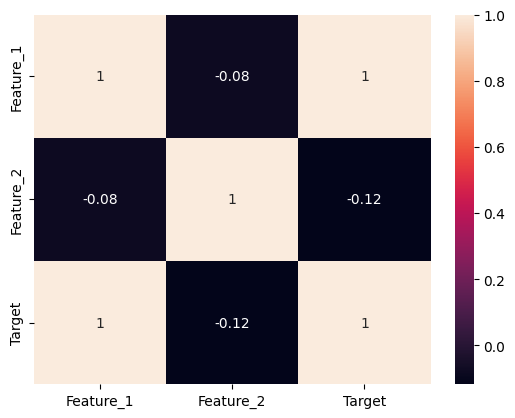

In [ ]:
# 1. Put the raw data into a simple dictionary
data = {
    "Feature_1": [0.1, 0.4, 0.7, 1.0, 1.3, 1.6, 1.9, 2.2],
    "Feature_2": [0.9, 0.1, 0.4, 0.8, 0.2, 0.7, 0.3, 0.6],
    "Target": [4.2, 5.1, 6.3, 6.9, 8.1, 8.7, 9.9, 10.5],
}

# 2. Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(data)

# 3. Calculate the correlation math automatically
matrix = df.corr()

# 4. Draw the heatmap and show it on the screen
sns.heatmap(matrix, annot=True)
plt.show()

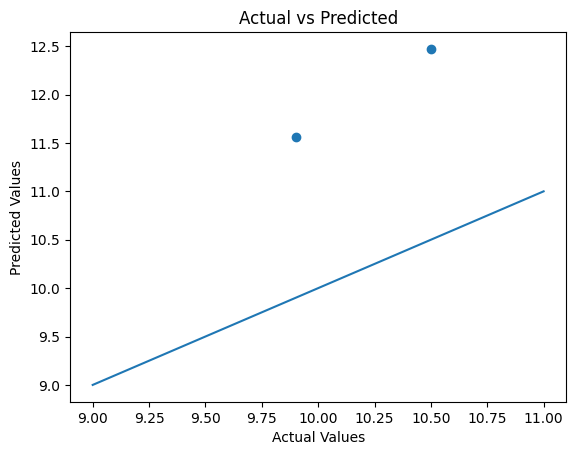

In [23]:
# 1. Setup the actual data and get predictions from our simple model
actual = [9.9, 10.5]
predicted = ols_model.predict(X_test)

# 2. Draw the data points as a scatter plot
plt.scatter(actual, predicted)

# 3. Draw a simple straight line from point (9,9) to (11,11) to show perfect guesses
plt.plot([9, 11], [9, 11])

# 4. Add simple text labels and show the window
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()